# Model Training
### 1.1 Import Data and Required Packages

### importing Pandas,Numpy,Matplotlib,Seaborn and Warnings Library.

In [13]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor,RandomForestRegressor
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV,train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('data/StudentsPerformance.csv')

show the Top 5 Records

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Preparing X and Y variables

In [7]:
X = df.drop(columns=['math score'],axis=1)

In [9]:
y = df['math score']

In [10]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns


from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer


numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScaler',numeric_transformer,num_features)
    ]
)

In [11]:
X = preprocessor.fit_transform(X)

In [14]:
# separate dataset into train and test

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)
X_train.shape,X_test.shape

((800, 19), (200, 19))

### Create an Evaluate Function to give all metrics after model training

In [16]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2score = r2_score(true,predicted)
    return mae,rmse,r2score

In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge":Ridge(),
    "K-Neighbors Regressor":KNeighborsRegressor(),
    "Decision Tress": DecisionTreeRegressor(),
    "Random Forest Regressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoosting Regressor":CatBoostRegressor(verbose=False),
    "AdaBoost Regressor":AdaBoostRegressor()
}

model_list = []
r2_list = []


for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train) # model train

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test datasets

    model_train_mae,model_train_rmse,model_train_r2 = evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2 = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])


    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('---------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')


    
    




Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3157
- Mean Absolute Error: 4.2396
- R2 Score: 0.8790
---------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3867
- Mean Absolute Error: 4.3025
- R2 Score: 0.8600


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5200
- Mean Absolute Error: 5.1439
- R2 Score: 0.8180
---------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.2863
- Mean Absolute Error: 4.9479
- R2 Score: 0.8093


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3159
- Mean Absolute Error: 4.2390
- R2 Score: 0.8790
---------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3846
- Mean Absolute Error: 4.2985
- R2 Score: 0.8601


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.8827
- Mean Absolute Error: 4.6285
- R2 Score: 0.8518
--------------------------

### Linear Regression

In [24]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 86.00


### Plot y_pred and y_test 

Text(0, 0.5, 'Predicted')

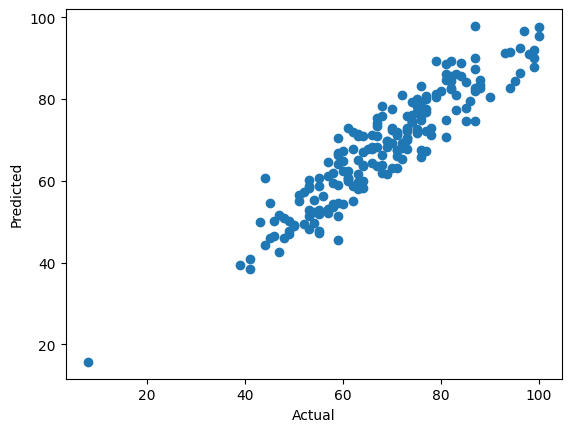

In [25]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math score'>

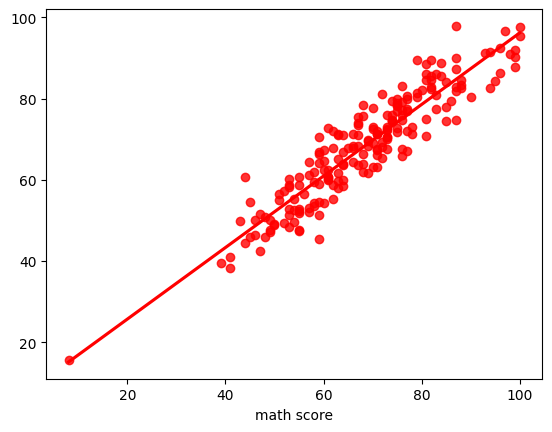

In [27]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

### Difference between Actual and Predicted Values

In [28]:
pred_df = pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
249,68,61.878718,6.121282
353,46,50.199983,-4.199983
537,51,56.545091,-5.545091
424,41,40.872364,0.127636
564,48,50.901322,-2.901322
...,...,...,...
684,62,71.996229,-9.996229
644,70,69.172375,0.827625
110,77,80.680412,-3.680412
28,70,72.968568,-2.968568
